In [3]:
from pathlib import Path

dataset_path = Path("../../data/item_images/raw/unu")

In [4]:
for item in dataset_path.iterdir():
    print(item.name)

README.dataset.txt
README.roboflow.txt
test
train
valid


In [5]:
for path in dataset_path.rglob("*"):
    if path.is_dir():
        print(path)

..\..\data\item_images\raw\unu\test
..\..\data\item_images\raw\unu\train
..\..\data\item_images\raw\unu\valid


Locate all JSON files

In [6]:
json_files = list(dataset_path.rglob("*.json"))

for file in json_files:
    print(file)

..\..\data\item_images\raw\unu\test\_annotations.coco.json
..\..\data\item_images\raw\unu\train\_annotations.coco.json
..\..\data\item_images\raw\unu\valid\_annotations.coco.json


In [7]:
import json

with open(json_files[0], "r", encoding="utf-8") as f:
    data = json.load(f)

print(data.keys())

dict_keys(['info', 'licenses', 'categories', 'images', 'annotations'])


In [8]:
print("Images:", len(data["images"]))
print("Annotations:", len(data["annotations"]))
print("Categories:", len(data["categories"]))

Images: 1960
Annotations: 2899
Categories: 78


Find the exact phone category IDs

In [9]:
for category in data["categories"]:
    name = category["name"]

    if "phone" in name.lower():
        print(category)

{'id': 2, 'name': 'Bar-Phone', 'supercategory': 'Electronic-Waste'}
{'id': 37, 'name': 'Headphone', 'supercategory': 'Electronic-Waste'}
{'id': 61, 'name': 'Smartphone', 'supercategory': 'Electronic-Waste'}
{'id': 71, 'name': 'Telephone-Set', 'supercategory': 'Electronic-Waste'}


count actual usable phone data across all 3 splits

In [10]:
phone_ids = {
    2: "Bar-Phone",
    61: "Smartphone"
}

split_counts = {}
total_object_counts = {
    "Bar-Phone": 0,
    "Smartphone": 0
}

total_image_counts = {
    "Bar-Phone": 0,
    "Smartphone": 0
}

for json_file in json_files:

    split = json_file.parent.name

    with open(json_file, "r", encoding="utf-8") as f:
        data = json.load(f)

    image_ids_by_class = {
        "Bar-Phone": set(),
        "Smartphone": set()
    }

    object_counts = {
        "Bar-Phone": 0,
        "Smartphone": 0
    }

    for ann in data["annotations"]:

        category_id = ann["category_id"]

        if category_id in phone_ids:

            class_name = phone_ids[category_id]

            object_counts[class_name] += 1
            image_ids_by_class[class_name].add(
                ann["image_id"]
            )

    split_counts[split] = {}

    for class_name in phone_ids.values():

        image_count = len(
            image_ids_by_class[class_name]
        )

        split_counts[split][class_name] = {
            "images": image_count,
            "objects": object_counts[class_name]
        }

        total_image_counts[class_name] += image_count
        total_object_counts[class_name] += object_counts[class_name]


print("Split-wise:")
for split, counts in split_counts.items():
    print("\n", split)
    print(counts)

print("\nTOTAL IMAGES:")
print(total_image_counts)

print("\nTOTAL OBJECTS:")
print(total_object_counts)

print(
    "\nTOTAL PHONE IMAGES:",
    sum(total_image_counts.values())
)

Split-wise:

 test
{'Bar-Phone': {'images': 9, 'objects': 9}, 'Smartphone': {'images': 103, 'objects': 119}}

 train
{'Bar-Phone': {'images': 80, 'objects': 84}, 'Smartphone': {'images': 667, 'objects': 821}}

 valid
{'Bar-Phone': {'images': 21, 'objects': 22}, 'Smartphone': {'images': 173, 'objects': 222}}

TOTAL IMAGES:
{'Bar-Phone': 110, 'Smartphone': 943}

TOTAL OBJECTS:
{'Bar-Phone': 115, 'Smartphone': 1162}

TOTAL PHONE IMAGES: 1053


Build one clean dataframe for all phone annotations

In [11]:
import pandas as pd
import json
import re
from pathlib import Path

PHONE_IDS = {
    2: "Bar-Phone",
    61: "Smartphone"
}


def get_source_group(file_name):
    """
    Remove Roboflow's .rf.<hash> part so variants originating
    from the same source filename receive the same group ID.
    """

    stem = Path(file_name).stem

    # Example:
    # 468_jpeg.rf.abc123 -> 468_jpeg
    base = stem.split(".rf.")[0]

    # remove Roboflow's original extension marker
    base = re.sub(
        r"_(jpg|jpeg|png|webp)$",
        "",
        base,
        flags=re.IGNORECASE
    )

    return base


rows = []

for json_file in json_files:

    split = json_file.parent.name

    with open(json_file, "r", encoding="utf-8") as f:
        data = json.load(f)

    image_lookup = {
        img["id"]: img
        for img in data["images"]
    }

    for ann in data["annotations"]:

        if ann["category_id"] not in PHONE_IDS:
            continue

        img = image_lookup[ann["image_id"]]

        x, y, w, h = ann["bbox"]

        rows.append({
            "split": split,
            "annotation_id": ann["id"],
            "image_id": ann["image_id"],
            "file_name": img["file_name"],
            "source_group_id": get_source_group(img["file_name"]),
            "original_class_id": ann["category_id"],
            "original_label": PHONE_IDS[ann["category_id"]],
            "esafe_label": "mobile_phone",
            "image_width": img["width"],
            "image_height": img["height"],
            "bbox_x": x,
            "bbox_y": y,
            "bbox_width": w,
            "bbox_height": h,
            "bbox_area_ratio": (w * h) / (
                img["width"] * img["height"]
            ),
            "has_segmentation": bool(
                ann.get("segmentation")
            ),
            "iscrowd": ann.get("iscrowd", 0)
        })


phone_df = pd.DataFrame(rows)

print(phone_df.shape)
phone_df.head()

(1277, 17)


,split,annotation_id,image_id,file_name,source_group_id,original_class_id,original_label,esafe_label,image_width,image_height,bbox_x,bbox_y,bbox_width,bbox_height,bbox_area_ratio,has_segmentation,iscrowd
0,test,16,12,553_jpg.rf.0385c96b020b4a85685dd3573067b2b3.jpg,553,61,Smartphone,mobile_phone,640,640,141,50,359.00,507.000,0.444368,False,0
1,test,46,32,samsung-galaxy-a54-5g-1-_jpeg.rf.053f270fbb010...,samsung-galaxy-a54-5g-1-,61,Smartphone,mobile_phone,640,640,178,106,278.40,426.667,0.290000,True,0
2,test,48,34,IMG-20200328-WA0031_jpg.rf.047d06107eac34f4a54...,IMG-20200328-WA0031,61,Smartphone,mobile_phone,640,640,174,62,275.00,536.000,0.359863,False,0
3,test,86,41,000000518080_jpg.rf.04393a45d8424902800a1a72f7...,000000518080,61,Smartphone,mobile_phone,640,640,437,451,67.49,36.730,0.006052,True,0
4,test,135,80,IMG_20200328_131720_jpg.rf.0ad012be39aa66620a8...,IMG_20200328_131720,61,Smartphone,mobile_phone,640,640,277,36,81.00,335.000,0.066248,False,0


one row per phone object, not one row per image

Verify the dataframe counts

In [12]:
print(
    phone_df["original_label"].value_counts()
)

print()

print(
    phone_df.groupby(
        ["split", "original_label"]
    ).size()
)

original_label
Smartphone    1162
Bar-Phone      115
Name: count, dtype: int64

split  original_label
test   Bar-Phone           9
       Smartphone        119
train  Bar-Phone          84
       Smartphone        821
valid  Bar-Phone          22
       Smartphone        222
dtype: int64


In [13]:
unique_phone_images = (
    phone_df[
        ["split", "image_id"]
    ]
    .drop_duplicates()
)

print(
    "Unique phone images:",
    len(unique_phone_images)
)

Unique phone images: 1049


Check annotation validity

In [14]:
invalid_boxes = []

for _, row in phone_df.iterrows():

    x = row["bbox_x"]
    y = row["bbox_y"]
    w = row["bbox_width"]
    h = row["bbox_height"]

    W = row["image_width"]
    H = row["image_height"]

    valid = (
        x >= 0 and
        y >= 0 and
        w > 0 and
        h > 0 and
        x + w <= W + 1 and
        y + h <= H + 1
    )

    if not valid:
        invalid_boxes.append(
            row[
                [
                    "split",
                    "file_name",
                    "annotation_id",
                    "bbox_x",
                    "bbox_y",
                    "bbox_width",
                    "bbox_height"
                ]
            ].to_dict()
        )


print(
    "Invalid/out-of-bounds boxes:",
    len(invalid_boxes)
)

print(invalid_boxes[:10])

Invalid/out-of-bounds boxes: 0
[]


In [15]:
print(
    "Crowd annotations:",
    phone_df["iscrowd"].sum()
)

print(
    "\nWith segmentation:",
    phone_df["has_segmentation"].value_counts()
)

Crowd annotations: 0

With segmentation: has_segmentation
False    836
True     441
Name: count, dtype: int64


Find the repeated images you noticed

In [16]:
group_sizes = (
    phone_df[
        [
            "split",
            "image_id",
            "file_name",
            "source_group_id"
        ]
    ]
    .drop_duplicates()
    .groupby("source_group_id")
    .size()
    .sort_values(ascending=False)
)


repeated_source_groups = group_sizes[
    group_sizes > 1
]


print(
    "Unique source groups:",
    phone_df["source_group_id"].nunique()
)

print(
    "Repeated source groups:",
    len(repeated_source_groups)
)

print(
    "\nLargest repeated groups:"
)

print(
    repeated_source_groups.head(20)
)

Unique source groups: 775
Repeated source groups: 208

Largest repeated groups:
source_group_id
483                    4
485                    4
IMG_20200329_152625    3
IMG_20200329_152704    3
464                    3
456                    3
458                    3
459                    3
520                    3
517                    3
518                    3
521                    3
522                    3
552                    3
457                    3
497                    3
462                    3
461                    3
505                    3
478                    3
dtype: int64


In [17]:
raw_unique_images = (
    phone_df[
        ["split", "image_id"]
    ]
    .drop_duplicates()
    .shape[0]
)

unique_source_images = (
    phone_df[
        "source_group_id"
    ]
    .nunique()
)

print(
    "Raw annotated phone images:",
    raw_unique_images
)

print(
    "Estimated unique source images:",
    unique_source_images
)

print(
    "Possible repeated/derived images:",
    raw_unique_images - unique_source_images
)

Raw annotated phone images: 1049
Estimated unique source images: 775
Possible repeated/derived images: 274


Check whether those groups leak across train/valid/test

In [18]:
group_splits = (
    phone_df[
        [
            "source_group_id",
            "split"
        ]
    ]
    .drop_duplicates()
    .groupby("source_group_id")["split"]
    .agg(lambda x: sorted(set(x)))
)


cross_split_groups = group_splits[
    group_splits.apply(len) > 1
]


print(
    "Source groups appearing across multiple splits:",
    len(cross_split_groups)
)

print(
    cross_split_groups.head(20)
)

Source groups appearing across multiple splits: 113
source_group_id
313           [test, train]
452    [test, train, valid]
453          [train, valid]
454          [train, valid]
456          [train, valid]
458           [test, train]
459          [train, valid]
460    [test, train, valid]
464          [train, valid]
466           [test, train]
467          [train, valid]
468           [test, valid]
471          [train, valid]
472          [train, valid]
473          [train, valid]
478           [test, train]
479          [train, valid]
480          [train, valid]
482           [test, train]
483    [test, train, valid]
Name: split, dtype: object


Check what Roboflow says it did

In [19]:
readme_path = dataset_path / "README.roboflow.txt"

if readme_path.exists():

    print(
        readme_path.read_text(
            encoding="utf-8",
            errors="ignore"
        )
    )


E-Waste Dataset - v44 Fix annotations of some bar-phones incorrectly labelled as smartphones

This dataset was exported via roboflow.com on June 11, 2024 at 7:47 PM GMT

Roboflow is an end-to-end computer vision platform that helps you
* collaborate with your team on computer vision projects
* collect & organize images
* understand and search unstructured image data
* annotate, and create datasets
* export, train, and deploy computer vision models
* use active learning to improve your dataset over time

For state of the art Computer Vision training notebooks you can use with this dataset,
visit https://github.com/roboflow/notebooks

To find over 100k other datasets and pre-trained models, visit https://universe.roboflow.com

The dataset includes 19613 images.
Electronic-Waste are annotated in COCO format.

The following pre-processing was applied to each image:
* Auto-orientation of pixel data (with EXIF-orientation stripping)
* Resize to 640x640 (Fit (black edges))

No image augmenta

Check how many phone objects occur in one image

In [20]:
phones_per_image = (
    phone_df
    .groupby(
        ["split", "image_id", "file_name"]
    )
    .size()
    .sort_values(ascending=False)
)


print(
    "Images with more than one annotated phone:",
    (phones_per_image > 1).sum()
)

print(
    "\nMaximum phones in one image:",
    phones_per_image.max()
)

print(
    "\nDistribution:"
)

print(
    phones_per_image.value_counts().sort_index()
)

Images with more than one annotated phone: 175

Maximum phones in one image: 6

Distribution:
1    874
2    144
3     20
4      4
5      3
6      4
Name: count, dtype: int64


Check Smartphone + Bar-Phone occurring together

In [21]:
classes_per_image = (
    phone_df
    .groupby(
        ["split", "image_id"]
    )["original_label"]
    .agg(lambda x: set(x))
)


both_types = classes_per_image[
    classes_per_image.apply(
        lambda x:
        "Smartphone" in x and
        "Bar-Phone" in x
    )
]


print(
    "Images containing both Smartphone and Bar-Phone:",
    len(both_types)
)

Images containing both Smartphone and Bar-Phone: 4


Check clutter from OTHER annotated classes

In [22]:
from collections import defaultdict, Counter

cooccurring_classes = Counter()

phone_images_with_other_classes = 0
total_phone_images_checked = 0


for json_file in json_files:

    split = json_file.parent.name

    with open(json_file, "r", encoding="utf-8") as f:
        data = json.load(f)

    category_lookup = {
        cat["id"]: cat["name"]
        for cat in data["categories"]
    }

    annotations_by_image = defaultdict(list)

    for ann in data["annotations"]:
        annotations_by_image[
            ann["image_id"]
        ].append(
            ann["category_id"]
        )

    phone_image_ids = {
        ann["image_id"]
        for ann in data["annotations"]
        if ann["category_id"] in PHONE_IDS
    }

    for image_id in phone_image_ids:

        total_phone_images_checked += 1

        classes = annotations_by_image[
            image_id
        ]

        other_classes = [
            category_lookup[c]
            for c in classes
            if c not in PHONE_IDS
        ]

        if other_classes:

            phone_images_with_other_classes += 1

            cooccurring_classes.update(
                other_classes
            )


print(
    "Phone images checked:",
    total_phone_images_checked
)

print(
    "Phone images containing other annotated classes:",
    phone_images_with_other_classes
)

print(
    "\nMost common co-occurring classes:"
)

print(
    cooccurring_classes.most_common(15)
)

Phone images checked: 1049
Phone images containing other annotated classes: 160

Most common co-occurring classes:
[('Laptop', 173), ('Computer-Keyboard', 104), ('Computer-Mouse', 82), ('Flat-Panel-Monitor', 74), ('Oven', 4), ('Headphone', 4), ('Tablet', 3), ('CRT-Monitor', 3), ('Speaker', 2), ('Smart-Watch', 1), ('Microwave', 1), ('Projector', 1)]


Draw the bounding boxes properly

In [23]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image


def find_split_image(split, file_name):

    possible_paths = [
        dataset_path / split / file_name,
        dataset_path / split / "images" / file_name
    ]

    for path in possible_paths:
        if path.exists():
            return path

    return None

In [24]:
def show_random_phone_annotations(number=8):

    sampled_images = (
        phone_df[
            [
                "split",
                "image_id",
                "file_name"
            ]
        ]
        .drop_duplicates()
        .sample(
            min(
                number,
                phone_df[
                    ["split", "image_id"]
                ].drop_duplicates().shape[0]
            )
        )
    )


    for _, sample in sampled_images.iterrows():

        split = sample["split"]
        image_id = sample["image_id"]
        file_name = sample["file_name"]

        image_path = find_split_image(
            split,
            file_name
        )

        if image_path is None:
            continue

        img = Image.open(image_path)

        fig, ax = plt.subplots()

        ax.imshow(img)

        anns = phone_df[
            (phone_df["split"] == split) &
            (phone_df["image_id"] == image_id)
        ]

        for _, ann in anns.iterrows():

            x = ann["bbox_x"]
            y = ann["bbox_y"]
            w = ann["bbox_width"]
            h = ann["bbox_height"]

            rect = patches.Rectangle(
                (x, y),
                w,
                h,
                fill=False,
                linewidth=2
            )

            ax.add_patch(rect)

            ax.text(
                x,
                y,
                ann["original_label"],
                fontsize=8
            )

        ax.set_title(
            f"{split} | {file_name}"
        )

        ax.axis("off")

        plt.show()

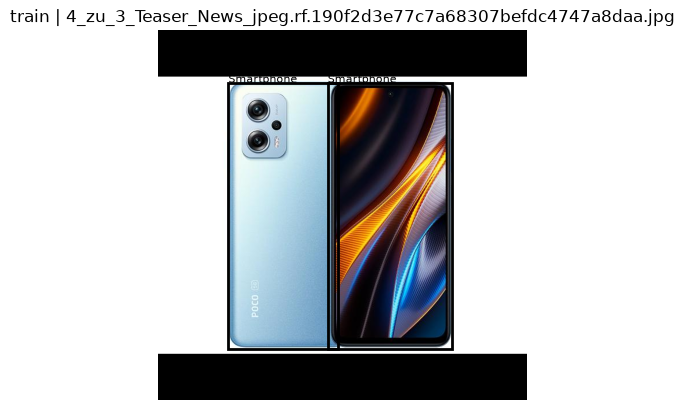

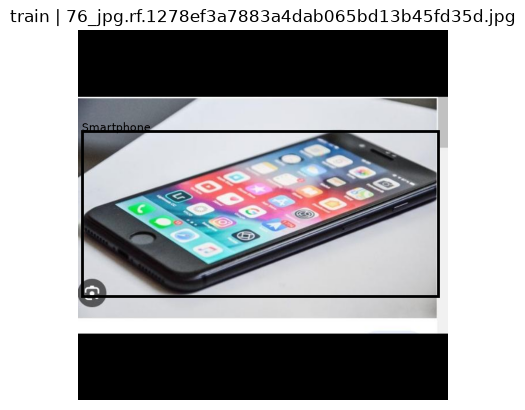

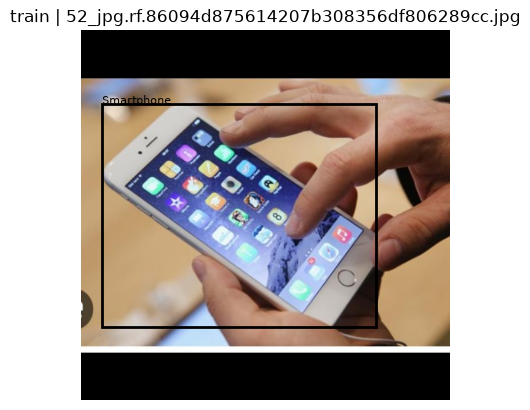

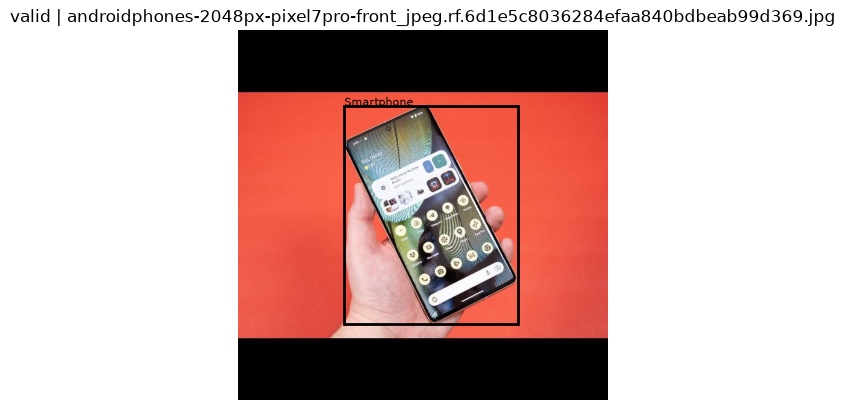

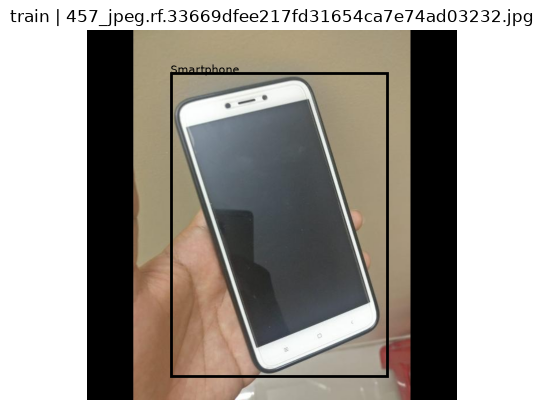

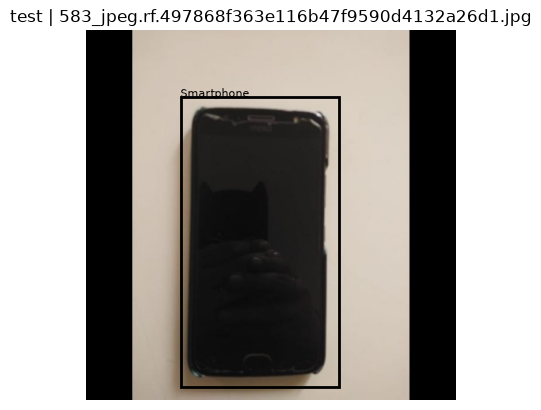

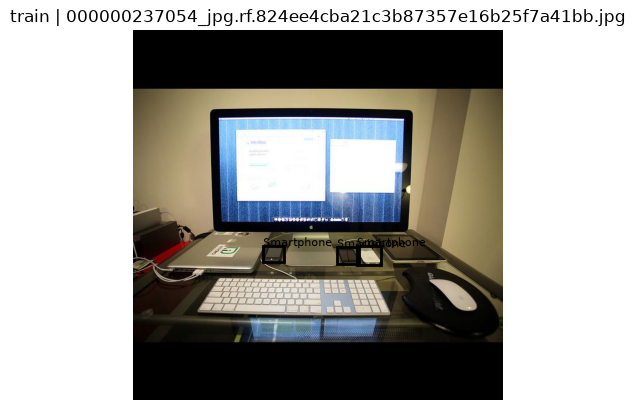

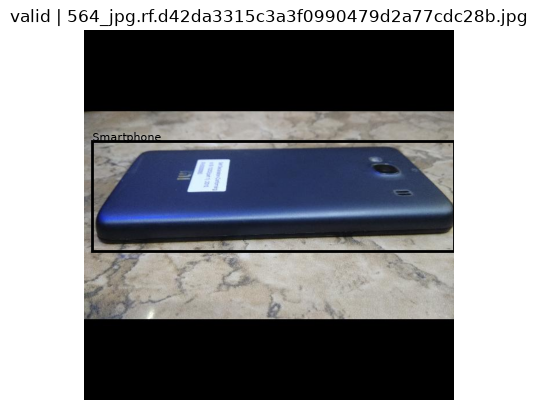

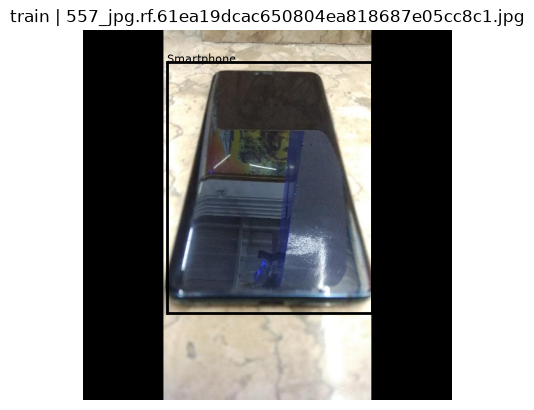

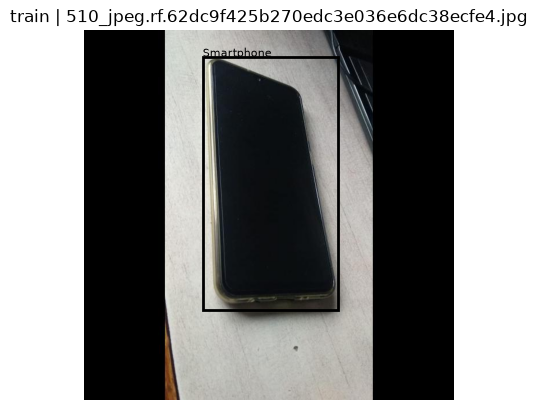

In [25]:
show_random_phone_annotations(10)

Check image dimensions

In [26]:
target_images = (
    phone_df[
        [
            "split",
            "image_id",
            "file_name",
            "image_width",
            "image_height"
        ]
    ]
    .drop_duplicates()
)


print(
    target_images[
        ["image_width", "image_height"]
    ]
    .value_counts()
)

image_width  image_height
640          640             1049
Name: count, dtype: int64


Check corrupt/missing files

In [27]:
corrupt_images = []
missing_images = []


for _, row in target_images.iterrows():

    image_path = find_split_image(
        row["split"],
        row["file_name"]
    )

    if image_path is None:

        missing_images.append(
            row["file_name"]
        )

        continue


    try:

        with Image.open(image_path) as img:
            img.verify()

    except Exception as e:

        corrupt_images.append(
            (
                row["file_name"],
                str(e)
            )
        )


print(
    "Missing phone images:",
    len(missing_images)
)

print(
    "Corrupt phone images:",
    len(corrupt_images)
)

Missing phone images: 0
Corrupt phone images: 0


Measure phone size in the image

In [28]:
for label in [
    "Smartphone",
    "Bar-Phone"
]:

    values = phone_df[
        phone_df["original_label"]
        == label
    ]["bbox_area_ratio"]

    print("\n", label)

    print(
        "Objects:",
        len(values)
    )

    print(
        "Average area ratio:",
        values.mean()
    )

    print(
        "Median:",
        values.median()
    )

    print(
        "Minimum:",
        values.min()
    )

    print(
        "Maximum:",
        values.max()
    )


 Smartphone
Objects: 1162
Average area ratio: 0.24813478650053405
Median: 0.245654296875
Minimum: 0.000734765625
Maximum: 0.9922021484375

 Bar-Phone
Objects: 115
Average area ratio: 0.09890712036247454
Median: 0.0908203125
Minimum: 0.0007698559570312501
Maximum: 0.40989990234375


check very tiny phones

In [29]:
print(
    "Objects occupying < 2% of image:",
    (
        phone_df["bbox_area_ratio"]
        < 0.02
    ).sum()
)

print(
    "Objects occupying < 5% of image:",
    (
        phone_df["bbox_area_ratio"]
        < 0.05
    ).sum()
)

Objects occupying < 2% of image: 105
Objects occupying < 5% of image: 177


Visualize smallest phone annotations

In [30]:
smallest = (
    phone_df
    .sort_values(
        "bbox_area_ratio"
    )
    .head(10)
)

smallest[
    [
        "file_name",
        "original_label",
        "bbox_area_ratio"
    ]
]

,file_name,original_label,bbox_area_ratio
65,000000282998_jpg.rf.877c8b8f7846609e84ac50c8b3...,Smartphone,0.000735
697,000000279375_jpg.rf.34dc3b6671489179fcb012a072...,Bar-Phone,0.000770
133,000000084648_jpg.rf.0222509c4098674e60966db0d2...,Smartphone,0.000801
840,000000509733_jpg.rf.e776188ae2cfdaf5b414d11358...,Smartphone,0.000905
475,000000097492_jpg.rf.f2a7ac38d38adb6f5312bbe991...,Smartphone,0.000906
474,000000097492_jpg.rf.f2a7ac38d38adb6f5312bbe991...,Smartphone,0.000911
473,000000097492_jpg.rf.f2a7ac38d38adb6f5312bbe991...,Smartphone,0.000956
300,000000169872_jpg.rf.37077fc330f922865f3792766d...,Smartphone,0.001003
166,000000423488_jpg.rf.98fb4e1d72eeff5d9c955adde0...,Smartphone,0.001078
449,000000478778_jpg.rf.5f29029aa8fc0a666ce802ccc7...,Bar-Phone,0.001296


In [31]:
phone_df.sort_values(
    "bbox_area_ratio",
    ascending=False
).head(10)[
    [
        "file_name",
        "original_label",
        "bbox_area_ratio"
    ]
]

,file_name,original_label,bbox_area_ratio
1120,06f92f5456da8509_jpg.rf.5ad591ff1972d68152a182...,Smartphone,0.992202
859,043c9868ec03c044_jpg.rf.ed11f3fe292026020e4f62...,Smartphone,0.937686
984,094d441c55f010a8_jpg.rf.865a41f7be9a85e68297cf...,Smartphone,0.869895
23,086dc776cf482d37_jpg.rf.2b75018d1e667c2e3ade06...,Smartphone,0.823438
535,hero-image-fill-size_1200x1200-v1657736399-1-_...,Smartphone,0.817937
183,12dc1d884d4cce18_jpg.rf.9ff81adf98f7a7a00cf9e6...,Smartphone,0.788486
530,27d7d2c93503d6bb_jpg.rf.fda4b6cfc2086a0343069e...,Smartphone,0.753506
171,Mobilephone-Oppo_jpg.rf.99ccea3254bf675dedf900...,Smartphone,0.747012
455,a4164e4b534c87b6_jpg.rf.62b8afa83f5bb33dfb20e2...,Smartphone,0.740625
583,15_jpg.rf.18ea569b8f0eb934ab2c897a863a1867.jpg,Smartphone,0.734883


Check exact duplicates

In [32]:
import hashlib
from collections import defaultdict


hash_to_files = defaultdict(list)


for _, row in target_images.iterrows():

    image_path = find_split_image(
        row["split"],
        row["file_name"]
    )

    if image_path is None:
        continue

    with open(image_path, "rb") as f:

        file_hash = hashlib.md5(
            f.read()
        ).hexdigest()


    hash_to_files[file_hash].append(
        (
            row["split"],
            row["file_name"]
        )
    )


exact_duplicate_groups = [
    files
    for files in hash_to_files.values()
    if len(files) > 1
]


print(
    "Exact duplicate groups:",
    len(exact_duplicate_groups)
)


for group in exact_duplicate_groups[:10]:

    print("\n", group)

Exact duplicate groups: 206

 [('test', '553_jpg.rf.0385c96b020b4a85685dd3573067b2b3.jpg'), ('train', '553_jpg.rf.233e2117b2ae9c9b9fb3b72865e21972.jpg')]

 [('test', 'IMG-20200328-WA0031_jpg.rf.047d06107eac34f4a54dd1c9cf8372a7.jpg'), ('train', 'IMG-20200328-WA0031_jpg.rf.51912409b4e1f1056f1e391bd5547bd6.jpg')]

 [('test', '528_jpeg.rf.11dd7d54c31c7b3bb0f27ffdeb402ed0.jpg'), ('train', '528_jpeg.rf.6f9d0df6c034cbfecce97de60752040a.jpg')]

 [('test', 'IMG_20200329_152625_jpg.rf.11ee0f5be3aa974ae445197efbb31373.jpg'), ('train', 'IMG_20200329_152625_jpg.rf.10a23abfd49da7d502ccf7dcee2460a9.jpg')]

 [('test', '517_jpg.rf.1059780725d8d96bfa370a9f24c162b1.jpg'), ('train', '517_jpg.rf.f0cac674011fa4a5fd43a9c453b01510.jpg'), ('valid', '517_jpg.rf.cc4d2b15b4adf763e3bb8e9ce836966b.jpg')]

 [('test', 'IMG_20200329_152635_jpg.rf.191fcac68e663a7dd071aa38f0aee934.jpg'), ('valid', 'IMG_20200329_152635_jpg.rf.19f3f94108f270094e7bd2e81607e78a.jpg')]

 [('test', '500_jpeg.rf.1cff31ee7d91ad982a56ded113722fc

Summary

In [33]:
print("===== UNU MOBILE SUMMARY =====")

print(
    "Phone annotation objects:",
    len(phone_df)
)

print(
    "Annotated phone images:",
    len(target_images)
)

print(
    "Estimated unique source groups:",
    phone_df["source_group_id"].nunique()
)

print(
    "Repeated source groups:",
    len(repeated_source_groups)
)

print(
    "Cross-split source groups:",
    len(cross_split_groups)
)

print(
    "Images with multiple phones:",
    (phones_per_image > 1).sum()
)

print(
    "Images with other annotated object classes:",
    phone_images_with_other_classes
)

print(
    "Invalid boxes:",
    len(invalid_boxes)
)

print(
    "Missing images:",
    len(missing_images)
)

print(
    "Corrupt images:",
    len(corrupt_images)
)

print(
    "Exact duplicate groups:",
    len(exact_duplicate_groups)
)

===== UNU MOBILE SUMMARY =====
Phone annotation objects: 1277
Annotated phone images: 1049
Estimated unique source groups: 775
Repeated source groups: 208
Cross-split source groups: 113
Images with multiple phones: 175
Images with other annotated object classes: 160
Invalid boxes: 0
Missing images: 0
Corrupt images: 0
Exact duplicate groups: 206


EDA MARKDOWN

## Final EDA Findings — UNU-KEY E-Waste v44 (Mobile Phone)

### Target Mapping

The following original UNU-KEY classes are used for the E-Safe `mobile_phone` class:

- Bar-Phone (category ID 2) → mobile_phone
- Smartphone (category ID 61) → mobile_phone

Headphone and Telephone-Set are not included.

---

### Dataset Format

The dataset is provided in COCO format.

Each relevant annotation contains a COCO bounding box in the format:

[x_min, y_min, width, height]

Some annotations additionally contain segmentation polygons, while others do not.

For Dataset A, segmentation is not required because every target annotation provides a valid bounding box. The bounding boxes will later be used to derive padded object crops.

The dataset README states that the following preprocessing was already applied by Roboflow:

- EXIF auto-orientation
- Resize to 640 × 640 using Fit with black padding where necessary

No image augmentation was applied by Roboflow.

---

### Target Counts

Total phone annotation objects: 1277

- Smartphone objects: 1162
- Bar-Phone objects: 115

Distinct images containing at least one phone: 1049

The earlier sum of per-class image counts was 1053:

- Smartphone images: 943
- Bar-Phone images: 110

However, 4 images contain both Smartphone and Bar-Phone, so the actual number of distinct phone images is 1049.

Original split object counts:

Train:
- Smartphone: 821
- Bar-Phone: 84

Validation:
- Smartphone: 222
- Bar-Phone: 22

Test:
- Smartphone: 119
- Bar-Phone: 9

---

### Multiple Objects

175 images contain more than one annotated phone.

Maximum annotated phones in a single image: 6

Distribution:

- 874 images contain 1 phone
- 144 images contain 2 phones
- 20 images contain 3 phones
- 4 images contain 4 phones
- 3 images contain 5 phones
- 4 images contain 6 phones

4 images contain both Smartphone and Bar-Phone.

During preprocessing, each phone annotation can potentially generate an individual padded crop, while all crops originating from the same image must remain in the same final dataset split.

---

### Other Objects and Scene Clutter

160 of the 1049 phone images contain other annotated electronic classes.

The most frequent co-occurring classes include:

- Laptop
- Computer-Keyboard
- Computer-Mouse
- Flat-Panel-Monitor
- Headphone
- Tablet
- CRT-Monitor
- Speaker

Some phones are also partially occluded by hands or surrounding objects.

The bounding boxes generally isolate the phone correctly, so these cluttered scenes can still be useful after annotation-based cropping.

---

### Image Dimensions and Integrity

All 1049 phone images are 640 × 640.

Invalid or out-of-bounds target bounding boxes: 0

Missing phone images: 0

Corrupt phone images: 0

Crowd annotations: 0

Therefore, the basic annotation-to-image mapping and image integrity are satisfactory.

---

### Object Size

Smartphone:

- Objects: 1162
- Mean bbox area ratio: 24.81%
- Median bbox area ratio: 24.57%
- Minimum bbox area ratio: 0.073%
- Maximum bbox area ratio: 99.22%

Bar-Phone:

- Objects: 115
- Mean bbox area ratio: 9.89%
- Median bbox area ratio: 9.08%
- Minimum bbox area ratio: 0.077%
- Maximum bbox area ratio: 40.99%

Across both classes:

- 105 objects occupy less than 2% of the image
- 177 objects occupy less than 5% of the image

Manual inspection showed that many small annotations are valid phones. However, extremely small objects may contain insufficient original pixel information even after resizing and will therefore be flagged for review during preprocessing.

Very large bounding boxes are not automatically invalid. Some correspond to valid close-up phone photographs. Extremely zoomed or heavily clipped examples will be manually reviewed before inclusion.

---

### Background and Visual Diversity

Unlike the previous Bangladeshi source, the UNU dataset contains substantial background diversity.

Observed backgrounds include:

- white/product-style backgrounds
- tables
- rooms
- bedrooms
- desks
- hands holding phones
- indoor environments
- scenes containing other electronics

Lighting and orientation are also varied.

This diversity is useful for reducing background shortcut learning.

Some exported images contain black borders because Roboflow resized images to 640 × 640 using Fit rather than Stretch. These borders are a source-specific preprocessing artifact and should not be allowed to become a model shortcut.

---

### Device Condition

Most manually inspected phones appear clean or normal rather than visibly damaged.

This is acceptable for Dataset A because Dataset A is responsible for identifying the item class (`mobile_phone`), while visible damage and hazard recognition will be handled separately in Dataset B.

Real-world damaged and e-waste-like appearance will still need to be represented through other sources and the final real-world validation set.

---

### Duplicate and Leakage Analysis

Estimated source groups: 775

Repeated source groups: 208

Possible repeated/derived images based on source filename grouping: 274

113 source groups appear in more than one of the original train/validation/test splits.

Exact duplicate groups detected using MD5: 206

Several exact duplicate images occur across the original train, validation, and test splits.

The dataset README states that no augmentation was applied, so these repeated images are not Roboflow-generated augmentation variants. They appear to originate from duplication/repetition in the source collection.

Therefore, the original UNU train/validation/test split MUST NOT be used directly for final E-Safe evaluation.

Before training:

1. Exact duplicates will be removed.
2. Related source images will receive a common source/group ID.
3. All objects/crops derived from the same image or source group will remain in the same split.
4. A new group-aware train/validation/test split will be created after all Dataset A sources have been combined.

---

### Annotation Quality

Manual inspection showed that the phone bounding boxes generally:

- correctly locate the target phone
- contain the complete phone where it is visible
- remain useful in cluttered scenes
- correctly identify multiple phones independently

Some phones are naturally partially occluded by hands or other objects.

Moderate occlusion will be retained because similar situations may occur during real-world use.

---

## Final Decision

UNU-KEY E-Waste v44 will be retained as the main supplementary source for the E-Safe `mobile_phone` class.

Its major strengths are:

- large number of phone samples
- high background diversity
- varied lighting
- varied orientations
- product-style and real-world scenes
- multiple-phone scenes
- accurate COCO bounding boxes

Its major limitations are:

- substantial exact duplication
- duplicate leakage across the provided splits
- some extremely small phone instances
- some extremely zoomed-in phone instances
- most phones appear clean/new rather than damaged
- source-specific black padding is present in some resized images

These limitations are considered manageable through deduplication, group-aware splitting, padded bounding-box cropping, extreme-size review, and final real-world validation.

The raw dataset will remain unchanged.

In [34]:
import hashlib

image_md5 = {}

for _, row in target_images.iterrows():

    key = (
        row["split"],
        row["image_id"]
    )

    image_path = find_split_image(
        row["split"],
        row["file_name"]
    )

    with open(image_path, "rb") as f:
        image_md5[key] = hashlib.md5(
            f.read()
        ).hexdigest()

In [35]:
from collections import defaultdict

other_classes_by_image = {}

for json_file in json_files:

    split = json_file.parent.name

    with open(
        json_file,
        "r",
        encoding="utf-8"
    ) as f:
        data = json.load(f)

    category_lookup = {
        c["id"]: c["name"]
        for c in data["categories"]
    }

    annotations_by_image = defaultdict(list)

    for ann in data["annotations"]:
        annotations_by_image[
            ann["image_id"]
        ].append(
            ann["category_id"]
        )

    for image_id, class_ids in annotations_by_image.items():

        others = sorted({
            category_lookup[class_id]
            for class_id in class_ids
            if class_id not in PHONE_IDS
        })

        other_classes_by_image[
            (split, image_id)
        ] = others

In [36]:
manifest_df = phone_df.copy()

manifest_df.rename(
    columns={
        "split": "original_split"
    },
    inplace=True
)


manifest_df.insert(
    0,
    "sample_id",
    [
        f"UNUM{i:05d}"
        for i in range(
            1,
            len(manifest_df) + 1
        )
    ]
)


manifest_df.insert(
    1,
    "source_dataset",
    "UNU-KEY E-Waste Dataset v44"
)


manifest_df.insert(
    2,
    "license",
    "CC BY 4.0"
)

In [37]:
manifest_df["image_md5"] = manifest_df.apply(
    lambda row: image_md5[
        (
            row["original_split"],
            row["image_id"]
        )
    ],
    axis=1
)

In [38]:
phone_counts = (
    manifest_df
    .groupby(
        [
            "original_split",
            "image_id"
        ]
    )
    .size()
)


manifest_df["phone_count_in_image"] = (
    manifest_df.apply(
        lambda row: phone_counts.loc[
            (
                row["original_split"],
                row["image_id"]
            )
        ],
        axis=1
    )
)

In [39]:
manifest_df[
    "other_annotated_classes"
] = manifest_df.apply(

    lambda row: "; ".join(
        other_classes_by_image.get(
            (
                row["original_split"],
                row["image_id"]
            ),
            []
        )
    ),

    axis=1
)


manifest_df[
    "has_other_annotated_classes"
] = (
    manifest_df[
        "other_annotated_classes"
    ] != ""
)

In [40]:
manifest_df["tiny_object_flag"] = (
    manifest_df["bbox_area_ratio"] < 0.02
)

manifest_df["very_large_object_flag"] = (
    manifest_df["bbox_area_ratio"] > 0.80
)

manifest_df["multi_phone_image"] = (
    manifest_df["phone_count_in_image"] > 1
)

In [41]:
cross_split_ids = set(
    cross_split_groups.index
)

manifest_df[
    "source_group_cross_split"
] = (
    manifest_df[
        "source_group_id"
    ].isin(cross_split_ids)
)

In [42]:
manifest_df["bbox_xmin"] = (
    manifest_df["bbox_x"]
)

manifest_df["bbox_ymin"] = (
    manifest_df["bbox_y"]
)

manifest_df["bbox_xmax"] = (
    manifest_df["bbox_x"]
    + manifest_df["bbox_width"]
)

manifest_df["bbox_ymax"] = (
    manifest_df["bbox_y"]
    + manifest_df["bbox_height"]
)

In [43]:
manifest_df[
    "preprocessing_status"
] = "pending_review"

In [44]:
print(manifest_df.shape)

print(
    manifest_df[
        "original_label"
    ].value_counts()
)

manifest_df.head()

(1277, 33)
original_label
Smartphone    1162
Bar-Phone      115
Name: count, dtype: int64


,sample_id,source_dataset,license,original_split,annotation_id,image_id,file_name,source_group_id,original_class_id,original_label,...,has_other_annotated_classes,tiny_object_flag,very_large_object_flag,multi_phone_image,source_group_cross_split,bbox_xmin,bbox_ymin,bbox_xmax,bbox_ymax,preprocessing_status
0,UNUM00001,UNU-KEY E-Waste Dataset v44,CC BY 4.0,test,16,12,553_jpg.rf.0385c96b020b4a85685dd3573067b2b3.jpg,553,61,Smartphone,...,False,False,False,False,True,141,50,500.00,557.000,pending_review
1,UNUM00002,UNU-KEY E-Waste Dataset v44,CC BY 4.0,test,46,32,samsung-galaxy-a54-5g-1-_jpeg.rf.053f270fbb010...,samsung-galaxy-a54-5g-1-,61,Smartphone,...,False,False,False,False,False,178,106,456.40,532.667,pending_review
2,UNUM00003,UNU-KEY E-Waste Dataset v44,CC BY 4.0,test,48,34,IMG-20200328-WA0031_jpg.rf.047d06107eac34f4a54...,IMG-20200328-WA0031,61,Smartphone,...,False,False,False,False,True,174,62,449.00,598.000,pending_review
3,UNUM00004,UNU-KEY E-Waste Dataset v44,CC BY 4.0,test,86,41,000000518080_jpg.rf.04393a45d8424902800a1a72f7...,000000518080,61,Smartphone,...,True,True,False,False,False,437,451,504.49,487.730,pending_review
4,UNUM00005,UNU-KEY E-Waste Dataset v44,CC BY 4.0,test,135,80,IMG_20200328_131720_jpg.rf.0ad012be39aa66620a8...,IMG_20200328_131720,61,Smartphone,...,False,False,False,False,False,277,36,358.00,371.000,pending_review


In [45]:
output_path = (
    "../../data/metadata/"
    "unu_mobile_manifest.csv"
)

manifest_df.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)

Saved: ../../data/metadata/unu_mobile_manifest.csv


In [46]:
print(
    "Raw phone images:",
    len(target_images)
)

print(
    "Unique exact image hashes:",
    len(set(image_md5.values()))
)

print(
    "Images removable through exact deduplication:",
    len(target_images)
    - len(set(image_md5.values()))
)

Raw phone images: 1049
Unique exact image hashes: 782
Images removable through exact deduplication: 267
